In [53]:
import pandas as pd 

In [54]:
df_1 = pd.read_csv('../../data/MCAR.csv')
df_2 = pd.read_csv('../../data/MAR.csv')

In [55]:
df_1.head()

,EmployeeID,Age,Experience,Salary,Rating,Department,Gender,Education,Region,Projects
0,E001,25,2.0,4200.0,3.8,IT,M,Bachelor,Addis,3
1,E002,29,5.0,5500.0,4.2,Marketing,F,Master,Adama,4
2,E003,31,7.0,6100.0,4.5,Finance,M,Master,BahirDar,5
3,E004,26,3.0,NaN,3.9,HR,F,Bachelor,Hawassa,2
4,E005,34,9.0,7200.0,4.8,IT,M,PhD,Addis,6


In [56]:
df_2.head()

,EmployeeID,Age,Experience,Salary,Rating,Department,Gender,Education,Region,Projects
0,E001,25,2,4200.0,NaN,IT,M,Bachelor,Addis,3
1,E002,29,5,NaN,4.2,Marketing,F,Master,Adama,4
2,E003,31,7,NaN,4.5,Marketing,M,Master,BahirDar,5
3,E004,26,3,4600.0,NaN,HR,F,Bachelor,Hawassa,2
4,E005,34,9,7200.0,4.8,IT,M,PhD,Addis,6


Indetify whether it is MCAR or MAR and Indetify which Imputation should we use model based or others 

1.using corr for numeric columns

In [57]:
df_1.isnull().sum()

EmployeeID    0
Age           0
Experience    1
Salary        4
Rating        2
Department    0
Gender        0
Education     0
Region        0
Projects      0
dtype: int64

In [58]:
# we have used corr for numerical relation 
num_cols_1 = df_1.select_dtypes(include= 'number')
num_cols_2 = df_2.select_dtypes(include= 'number')

df_1['Salary'] = df_1["Salary"].isnull().astype(int)
df_1['Rating'] = df_1["Rating"].isnull().astype(int)
df_1.corr(numeric_only= True)['Salary']
# here no ralation it might be MCAR 

Age           0.195893
Experience    0.182742
Salary        1.000000
Rating       -0.166667
Projects      0.128366
Name: Salary, dtype: float64

In [64]:
# using crosstab or chi-square for categorical one 
from scipy.stats import chi2_contingency
cat_cols = df_1.select_dtypes(include='object')
for col in cat_cols:
    cross_tab = pd.crosstab(df_1[col] , df_1['Salary'])
    chi_value , p_value , dof , ex = chi2_contingency(cross_tab)
    print(col)
    print(chi_value)
    print(p_value)
    print('-----')



EmployeeID
20.000000000000004
0.3945781820860007
-----
Department
0.0
1.0
-----
Gender
0.0
1.0
-----
Education
0.9027777777777778
0.6367431716784095
-----
Region
11.145833333333334
0.024973026025398026
-----


In [ ]:
#checking using group by 
   
df_1.groupby('Rating')['Salary'].apply(lambda x:x.isnull().sum())

Rating
0    0
1    0
Name: Salary, dtype: int64

In [61]:
df_2.isnull().sum()

EmployeeID    0
Age           0
Experience    0
Salary        8
Rating        4
Department    0
Gender        0
Education     0
Region        0
Projects      0
dtype: int64

In [ ]:
def check(nums):
    max_value = 0
    nums.sort()
    for i in range(len(nums)):
        count = 0
        for j in range(i , len(nums)-1):
            if nums[j+1] - nums[j] == 1:
                count += 1
        max_value = max(max_value , count)
    return max_value

print(check[100,4,200,1,3,2])

In [62]:
df_2['Salary'] = df_2['Salary'].isnull().astype(int)
df_2.corr(numeric_only=True)['Salary']
# Here there is ralation so it might be MAR

Age          -0.264526
Experience   -0.227915
Salary        1.000000
Rating       -0.768405
Projects     -0.248925
Name: Salary, dtype: float64

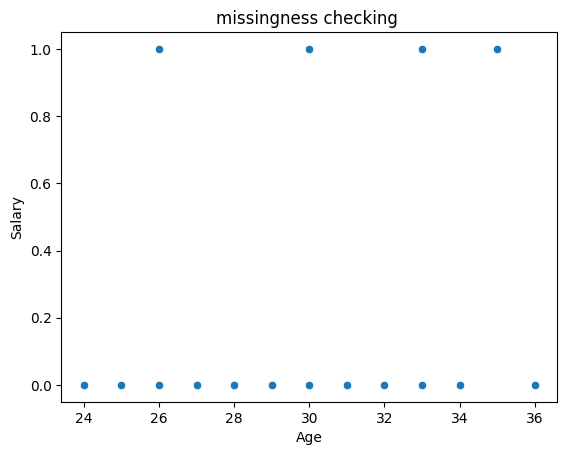

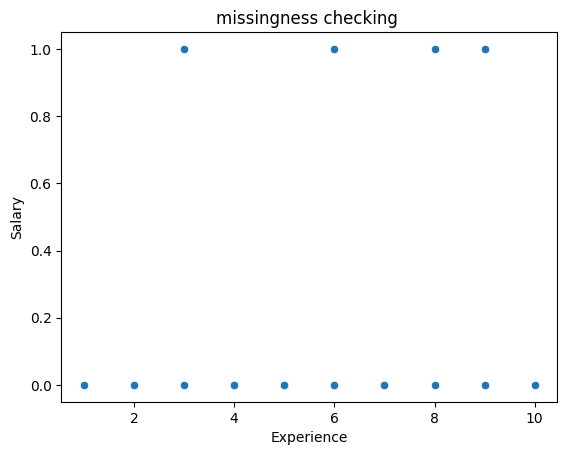

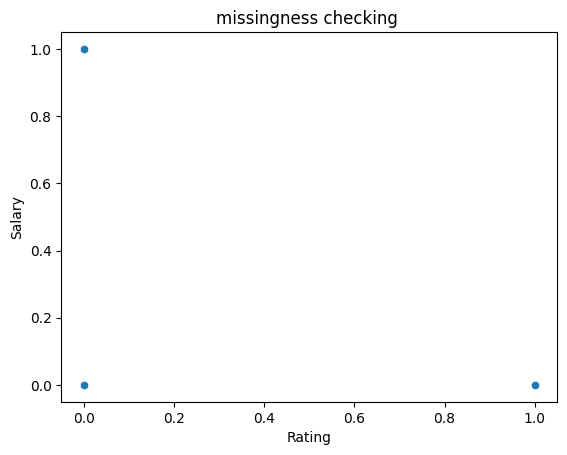

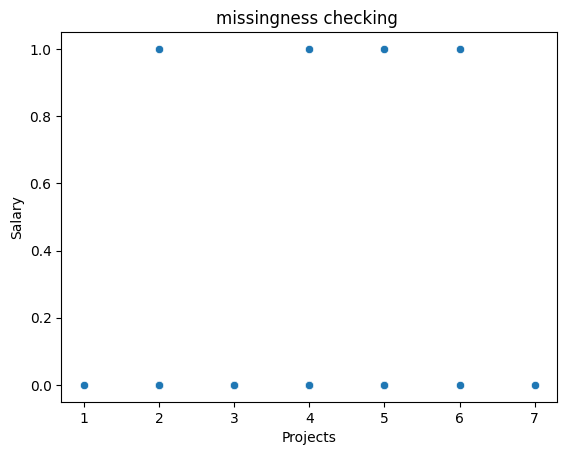

In [72]:
# lets see using visual pics

import seaborn as sns 
import matplotlib.pyplot as plt 
for col in num_cols_1:
    if col != 'Salary':
        sns.scatterplot(x = df_1[col] , y= df_1['Salary'] , data=df_1)
        plt.xlabel(col)
        plt.ylabel('Salary')
        plt.title('missingness checking ')
        plt.show()

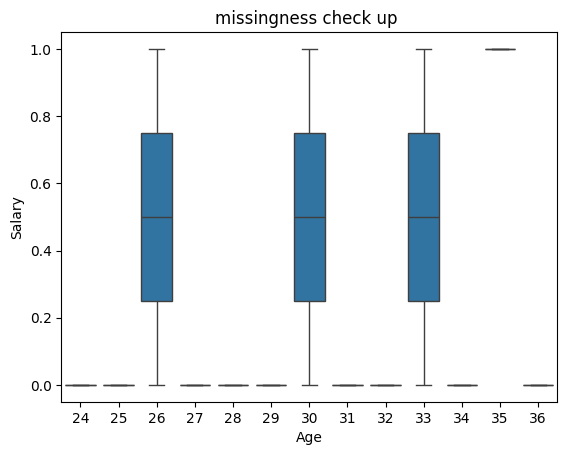

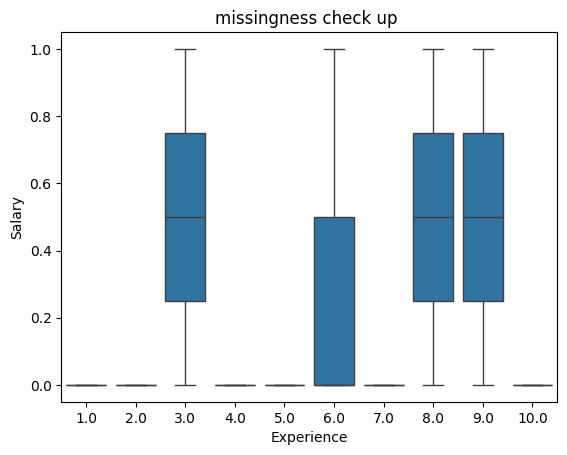

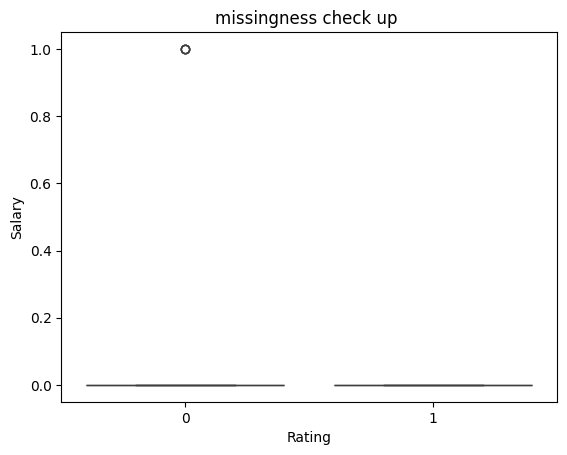

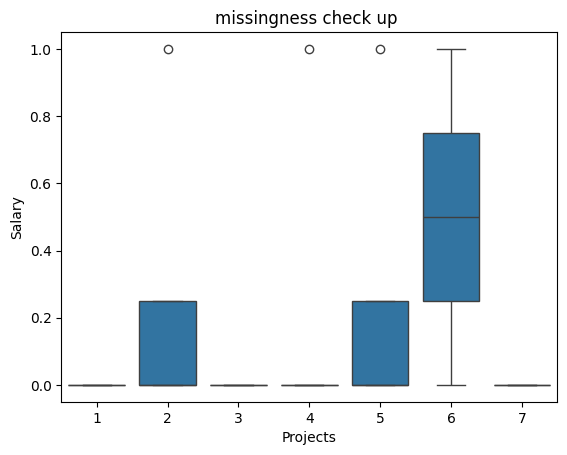

In [76]:
for col in num_cols_1:
    if col != 'Salary':
        sns.boxplot(x=col , y= df_1['Salary'] , data= df_1)
        plt.xlabel(col)
        plt.ylabel('Salary')
        plt.title('missingness check up ')
        plt.show()